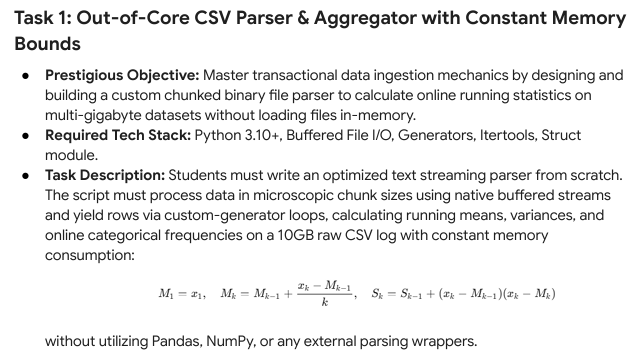

# Task 1: Out-of-Core CSV Parser & Aggregator with Constant Memory Bounds

## Subject
Python for Data Science

## Objective
Design and implement an optimized CSV parser from scratch that processes large datasets using constant memory.

## Requirements
- Python 3.10+
- Buffered File I/O
- Generators
- Itertools
- Struct Module (optional extension)
- No Pandas
- No NumPy
- No CSV Module

## Learning Outcomes
After completing this task, students will be able to:

1. Understand Out-of-Core Processing.
2. Process huge files without loading them into memory.
3. Use Python generators effectively.
4. Implement online statistical calculations.
5. Calculate running mean and variance.
6. Maintain categorical frequency counts.
7. Analyze memory-efficient data processing techniques.

# Introduction

Traditional data analysis tools load complete datasets into memory before processing.

For very large datasets (10GB or more), this becomes inefficient and may exceed available RAM.

Out-of-Core Processing solves this problem by:

- Reading small chunks of data
- Processing records one at a time
- Discarding processed records immediately

This ensures constant memory consumption regardless of dataset size.

# Mathematical Foundation

## Running Mean

Instead of storing all observations:

Mean = Sum / Count

we use an online update formula:

Mk = Mk-1 + (xk - Mk-1) / k

where:

- Mk = current mean
- Mk-1 = previous mean
- xk = new observation
- k = observation count

---

## Running Variance (Welford's Algorithm)

Sk = Sk-1 + (xk - Mk-1)(xk - Mk)

Variance = Sk / (n - 1)

Advantages:

- Numerically stable
- Memory efficient
- Suitable for streaming data

In [1]:
# Create sample dataset

sample_data = """TransactionID,Category,Amount
1001,Food,250
1002,Travel,800
1003,Food,300
1004,Shopping,1200
1005,Travel,450
1006,Food,100
1007,Bills,650
1008,Food,350
"""

with open("transaction.csv", "w") as file:
    file.write(sample_data)

print("Sample CSV file created successfully.")

Sample CSV file created successfully.


# Verify Dataset

The following code displays the contents of the generated CSV file.

In [2]:
with open("transaction.csv", "r") as file:
    print(file.read())

TransactionID,Category,Amount
1001,Food,250
1002,Travel,800
1003,Food,300
1004,Shopping,1200
1005,Travel,450
1006,Food,100
1007,Bills,650
1008,Food,350



# Generator-Based CSV Parser

A generator reads one row at a time.

Benefits:

- No large memory allocation
- Lazy evaluation
- Suitable for huge files

The keyword `yield` returns one record at a time.

In [3]:
def parse_csv(filename):
    
    with open(filename, "r", buffering=8192) as file:
        
        next(file)  # Skip header
        
        for line in file:
            
            line = line.strip()
            
            if not line:
                continue
                
            yield line.split(",")

# Testing the Generator

The following code demonstrates that rows are produced one-by-one rather than loading the entire file.

In [4]:
for row in parse_csv("transaction.csv"):
    print(row)

['1001', 'Food', '250']
['1002', 'Travel', '800']
['1003', 'Food', '300']
['1004', 'Shopping', '1200']
['1005', 'Travel', '450']
['1006', 'Food', '100']
['1007', 'Bills', '650']
['1008', 'Food', '350']


# Out-of-Core Aggregator

The following implementation computes:

1. Running Mean
2. Running Variance
3. Category Frequencies

using constant memory.

In [5]:
def process_file(filename):
    
    count = 0
    mean = 0
    M2 = 0
    
    category_frequency = {}
    
    for row in parse_csv(filename):
        
        transaction_id = row[0]
        category = row[1]
        amount = float(row[2])
        
        count += 1
        
        delta = amount - mean
        mean += delta / count
        
        delta2 = amount - mean
        M2 += delta * delta2
        
        if category in category_frequency:
            category_frequency[category] += 1
        else:
            category_frequency[category] = 1
    
    variance = M2 / (count - 1) if count > 1 else 0
    
    return count, mean, variance, category_frequency

# Execute Aggregation

Process the CSV file and compute the required statistics.

In [6]:
count, mean, variance, category_frequency = process_file("transaction.csv")

print("Total Records :", count)
print("Running Mean  :", round(mean, 2))
print("Variance      :", round(variance, 2))

print("\nCategory Frequencies")

for category, freq in category_frequency.items():
    print(category, ":", freq)

Total Records : 8
Running Mean  : 512.5
Variance      : 126964.29

Category Frequencies
Food : 4
Travel : 2
Shopping : 1
Bills : 1


# Memory Efficiency Discussion

Traditional Approach:

1. Read entire file.
2. Store all rows.
3. Perform calculations.

Memory Complexity:

O(n)

where n is the number of records.

---

Our Approach:

1. Read one row.
2. Process it.
3. Discard it.

Memory Complexity:

O(1)

This makes the solution scalable for very large datasets.

In [7]:
import os

file_size = os.path.getsize("transaction.csv")

print("File Size:", file_size, "bytes")

File Size: 161 bytes


# Complexity Analysis

## Time Complexity

Reading each record once:

O(n)

## Space Complexity

Only storing:

- Mean
- Variance accumulator
- Counter
- Category dictionary

Therefore:

O(1)

with respect to the number of records.

# Conclusion

An Out-of-Core CSV Parser was successfully implemented using:

- Buffered File I/O
- Generators
- Online Mean Calculation
- Online Variance Calculation
- Category Frequency Aggregation

The solution processes datasets efficiently while maintaining constant memory usage and avoiding external libraries such as Pandas and NumPy.

# Viva Questions

1. What is Out-of-Core Processing?
2. Why is constant memory important for big data?
3. What is a generator in Python?
4. What is the purpose of the yield keyword?
5. What is Buffered File I/O?
6. Explain Welford's Algorithm.
7. How is running mean different from traditional mean?
8. Why is Pandas unsuitable for very large files?
9. What is the time complexity of this solution?
10. What is the space complexity of this solution?

Q1. What is Out-of-Core Processing?

Answer:

Out-of-Core Processing is a technique used to process datasets that are too large to fit into the system's main memory (RAM). Instead of loading the entire dataset, it reads and processes small portions (chunks or rows) one at a time, keeping memory usage almost constant.

Q2. What is Constant Memory?

Answer:

Constant memory means the program uses approximately the same amount of memory regardless of the size of the input dataset. In this task, only one row is stored and processed at a time.

Q3. Why do we use Generators?

Answer:

Generators produce one value at a time using the yield keyword. They avoid storing the complete dataset in memory, making them suitable for large files and streaming applications.

Q4. What is the purpose of the yield keyword?

Answer:

The yield keyword pauses the function, returns one value, and resumes execution from the same point when called again. This enables lazy evaluation and efficient memory usage.

Q5. What is Buffered File I/O?

Answer:

Buffered File I/O reads data into a temporary memory buffer before the program accesses it. This reduces the number of disk operations and improves file-reading performance.

Q6. What is Welford's Algorithm?

Answer:

Welford's Algorithm is an online method for calculating the running mean and variance without storing all observations. It is numerically stable and works efficiently with streaming data.

Q7. Why not use Pandas for this task?

Answer:

Pandas typically loads the entire dataset into memory, which is not suitable for extremely large files (e.g., 10 GB or more). This task requires constant memory processing using only built-in Python features.

Q8. What is the time complexity of this program?

Answer:

The time complexity is O(n) because each record is processed exactly once.

Q9. What is the space complexity?

Answer:

The space complexity is O(1) with respect to the number of records because only a few variables and dictionaries (whose size depends on unique categories or cities, not total rows) are maintained.

Q10. What is a CSV file?

Answer:

A CSV (Comma-Separated Values) file is a plain text file used to store tabular data. Each line represents a record, and values are separated by commas.

Q11. What is a streaming parser?

Answer:

A streaming parser processes data sequentially as it is read from the file instead of loading the entire file into memory. This makes it suitable for handling very large datasets.

Q12. Why is online mean preferred over the traditional mean?

Answer:

The traditional mean requires storing all values or computing their total sum first. The online mean updates the average as each new value arrives, making it ideal for streaming data and memory-efficient applications.

# Assignment

## Task 1
Modify the parser to calculate the **running maximum** and **running minimum** transaction amount while processing the CSV file.

---

## Task 2
Calculate the **total transaction amount for each category** while maintaining constant memory.

---

## Task 3
Extend the parser to read a CSV file with five columns:

```
TransactionID,Date,Category,Amount,City
```

and count the number of transactions for each city.

In [8]:
def process_file_with_min_max(filename):

    count = 0
    mean = 0
    M2 = 0

    max_amount = float("-inf")
    min_amount = float("inf")

    category_frequency = {}

    for row in parse_csv(filename):

        category = row[1]
        amount = float(row[2])

        # Running Mean
        count += 1

        delta = amount - mean
        mean += delta / count

        delta2 = amount - mean
        M2 += delta * delta2

        # Running Maximum
        if amount > max_amount:
            max_amount = amount

        # Running Minimum
        if amount < min_amount:
            min_amount = amount

        # Category Frequency
        if category in category_frequency:
            category_frequency[category] += 1
        else:
            category_frequency[category] = 1

    variance = M2 / (count - 1) if count > 1 else 0

    return count, mean, variance, max_amount, min_amount, category_frequency

In [9]:
count, mean, variance, maximum, minimum, frequency = process_file_with_min_max("transaction.csv")

print("Total Records :", count)
print("Running Mean :", round(mean,2))
print("Variance :", round(variance,2))
print("Maximum Amount :", maximum)
print("Minimum Amount :", minimum)

print("\nCategory Frequency")

for key,value in frequency.items():
    print(key,":",value)

Total Records : 8
Running Mean : 512.5
Variance : 126964.29
Maximum Amount : 1200.0
Minimum Amount : 100.0

Category Frequency
Food : 4
Travel : 2
Shopping : 1
Bills : 1


In [10]:
## ASSIGNMENT 2 
def category_total_amount(filename):

    totals = {}

    for row in parse_csv(filename):

        category = row[1]
        amount = float(row[2])

        if category in totals:
            totals[category] += amount
        else:
            totals[category] = amount

    return totals

In [11]:
totals = category_total_amount("transaction.csv")

print("Total Amount per Category\n")

for category,total in totals.items():
    print(category,"=",total)

Total Amount per Category

Food = 1000.0
Travel = 1250.0
Shopping = 1200.0
Bills = 650.0


In [12]:
## ASSIGNMENT 3
data = """TransactionID,Date,Category,Amount,City
1001,2025-01-01,Food,250,Delhi
1002,2025-01-01,Travel,800,Mumbai
1003,2025-01-02,Food,300,Delhi
1004,2025-01-02,Shopping,1200,Chennai
1005,2025-01-03,Travel,450,Mumbai
1006,2025-01-04,Food,100,Delhi
1007,2025-01-04,Bills,650,Bangalore
1008,2025-01-05,Food,350,Delhi
"""

with open("transaction_city.csv","w") as file:
    file.write(data)

print("New CSV Created Successfully.")

New CSV Created Successfully.


In [13]:
def parse_city_csv(filename):

    with open(filename,"r") as file:

        next(file)

        for line in file:

            yield line.strip().split(",")

In [14]:
def city_transaction_count(filename):

    city_count = {}

    for row in parse_city_csv(filename):

        city = row[4]

        if city in city_count:
            city_count[city] += 1
        else:
            city_count[city] = 1

    return city_count

In [15]:
cities = city_transaction_count("transaction_city.csv")

print("Transactions per City\n")

for city,count in cities.items():
    print(city,":",count)

Transactions per City

Delhi : 4
Mumbai : 2
Chennai : 1
Bangalore : 1


# Traditional Approach: CSV Processing using Pandas and NumPy

## Subject
Python for Data Science

## Objective

In this notebook, we use the traditional data analysis approach by loading the complete CSV file into memory using **Pandas** and performing statistical analysis using **NumPy**.

This approach is simple and suitable for **small to medium-sized datasets**, but it is **not recommended for very large datasets** because the entire file is loaded into RAM.

# Import Required Libraries

We will use:

- **Pandas** for reading and manipulating CSV data.
- **NumPy** for performing numerical computations.

# TASK 1 OUT OF CORE PARSER 
## USING TRADITIONAL APPROACH

In [16]:
import pandas as pd
import numpy as np

# Load the CSV File

The file **transaction.csv** was created in the previous notebook.

Pandas loads the complete dataset into memory.

# Display the Dataset

Let's view the first few rows of the dataset.

In [19]:
import os
os.getcwd()

'C:\\Users\\Saksh\\OneDrive\\Desktop\\SDNB\\Tasks'

In [20]:
df = pd.read_csv(r"C:\\Users\\Saksh\\OneDrive\\Desktop\\SDNB\\Tasks\transaction.csv")

# Dataset Information

The following information includes:

- Number of rows
- Number of columns
- Data types
- Memory usage

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransactionID  8 non-null      int64 
 1   Category       8 non-null      object
 2   Amount         8 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes


# Basic Statistical Analysis

We calculate:

- Total number of transactions
- Mean transaction amount
- Variance
- Maximum amount
- Minimum amount

In [22]:
total_records = len(df)

mean_amount = np.mean(df["Amount"])

variance = np.var(df["Amount"], ddof=1)

maximum = np.max(df["Amount"])

minimum = np.min(df["Amount"])

print("Total Records :", total_records)
print("Mean Amount :", round(mean_amount,2))
print("Variance :", round(variance,2))
print("Maximum Amount :", maximum)
print("Minimum Amount :", minimum)

Total Records : 8
Mean Amount : 512.5
Variance : 126964.29
Maximum Amount : 1200
Minimum Amount : 100


# Category Frequency

We count how many transactions belong to each category.

In [23]:
category_frequency = df["Category"].value_counts()

category_frequency

Category
Food        4
Travel      2
Shopping    1
Bills       1
Name: count, dtype: int64

# Total Amount per Category

Using Pandas **groupby()**, we calculate the total transaction amount for each category.

In [24]:
total_amount = df.groupby("Category")["Amount"].sum()

total_amount

Category
Bills        650
Food        1000
Shopping    1200
Travel      1250
Name: Amount, dtype: int64

# Complete Statistical Summary

Pandas provides a built-in function to generate descriptive statistics.

In [25]:
df.describe()

,TransactionID,Amount
count,8.00000,8.000000
mean,1004.50000,512.500000
std,2.44949,356.320482
min,1001.00000,100.000000
25%,1002.75000,287.500000
50%,1004.50000,400.000000
75%,1006.25000,687.500000
max,1008.00000,1200.000000


# Memory Usage of DataFrame

Since Pandas loads the complete dataset into memory, we can check its memory usage.

In [26]:
memory = df.memory_usage(deep=True)

print(memory)

print("\nTotal Memory Used:", memory.sum(), "bytes")

Index            132
TransactionID     64
Category         433
Amount            64
dtype: int64

Total Memory Used: 693 bytes


# Advantages of the Traditional Approach

- Easy to write
- Less code
- Powerful built-in functions
- Excellent for small datasets
- Supports data visualization and machine learning libraries

# Limitations of the Traditional Approach

- Loads the entire dataset into RAM.
- High memory consumption.
- Not suitable for datasets larger than available memory.
- Performance decreases for very large datasets.

# Comparison: Traditional vs Out-of-Core Processing

| Feature | Traditional (Pandas & NumPy) | Out-of-Core Processing |
|----------|------------------------------|------------------------|
| Memory Usage | High | Constant |
| Reads Entire File | Yes | No |
| Suitable for Large Files | No | Yes |
| Speed (Small Files) | Fast | Moderate |
| External Libraries | Required | Not Required |
| Uses Generators | No | Yes |
| Streaming Support | No | Yes |

# Conclusion

The traditional approach using **Pandas** and **NumPy** is ideal for small and medium-sized datasets because it provides simple syntax and powerful analytical functions.

However, for extremely large datasets, loading the entire file into memory becomes inefficient. In such cases, an **Out-of-Core CSV Parser** using generators and buffered file I/O is a better choice because it processes data one record at a time while maintaining constant memory usage.

# Viva Questions with Answers
Q1. Why is Pandas widely used for data analysis?

Answer: Because it provides powerful functions for reading, cleaning, analyzing, filtering, grouping, and visualizing data with very little code.

Q2. What does pd.read_csv() do?

Answer: It reads a CSV file and loads its contents into a Pandas DataFrame.

Q3. Why is NumPy used in this notebook?

Answer: NumPy provides efficient numerical operations such as mean, variance, minimum, and maximum calculations.

Q4. What is a DataFrame?

Answer: A DataFrame is a two-dimensional tabular data structure in Pandas consisting of rows and columns.

Q5. What is the purpose of value_counts()?

Answer: It counts the frequency of unique values in a column.

Q6. What does groupby() do?

Answer: It groups rows based on a common column and performs aggregate operations such as sum, mean, count, or maximum.

Q7. What is the purpose of describe()?

Answer: It generates summary statistics such as count, mean, standard deviation, minimum, quartiles, and maximum for numerical columns.

Q8. Why is this approach called the traditional approach?

Answer: Because the entire dataset is loaded into memory before any analysis is performed, which is the standard method used in many data analysis workflows.

Q9. What is the main disadvantage of this approach?

Answer: It requires enough RAM to hold the complete dataset, making it unsuitable for very large files.

Q10. When should we prefer the Out-of-Core approach over the traditional approach?

Answer: We should use the Out-of-Core approach when working with datasets that are too large to fit into memory or when processing streaming data efficiently.